# Sleep Overview


What does my sleep look like?

Has my sleep changed over time?

What is a bad sleep?
What is a goood sleep?

Whats my best and worst ever sleeps?
My average sleep?


heat map of bedtime vs sleep length vs day of the week


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from src.helper import decimal_to_time

In [3]:
# The data
con = sqlite3.connect(r"C:\Users\Dexta\Learning\Garmin-Analysis\garminData\garmin.db")

sleep_raw = pd.read_sql(
    "SELECT * FROM Sleep",
    con
)

sleep_raw.head()

,calendarDate,sleepStartTimestampGMT,sleepEndTimestampGMT,deepSleepSeconds,lightSleepSeconds,remSleepSeconds,awakeSleepSeconds,totalSleepSeconds,averageRespiration,lowestRespiration,...,lightScore,awakeningsCountScore,awakeTimeScore,combinedAwakeScore,restfulnessScore,feedback,averageSPO2,averageHR,lowestSPO2,interruptionsScore
0,2022-03-12,2022-03-11T21:57:00.0,2022-03-12T06:23:00.0,720,19680,7200,2760,27600,13.0,8.0,...,62,40,54,47,33,NEGATIVE_LIGHT,94.0,47.0,88.0,None
1,2022-03-13,2022-03-12T21:06:00.0,2022-03-13T06:38:00.0,1860,22740,7740,1980,32340,13.0,8.0,...,64,65,67,66,67,POSITIVE_LONG_AND_RECOVERING,94.0,48.0,89.0,None
2,2022-03-14,2022-03-13T22:41:00.0,2022-03-14T06:28:00.0,540,20400,5940,1140,26880,12.0,6.0,...,33,87,81,84,62,POSITIVE_RECOVERING,94.0,48.0,91.0,None
3,2022-03-15,2022-03-14T22:10:00.0,2022-03-15T06:03:00.0,3900,16020,6300,2160,26220,13.0,6.0,...,84,65,64,64,67,POSITIVE_REFRESHING,95.0,48.0,86.0,None
4,2022-03-16,2022-03-15T21:41:00.0,2022-03-16T06:46:00.0,2760,20520,7200,2220,30480,15.0,7.0,...,70,75,63,69,71,POSITIVE_LONG_AND_REFRESHING,94.0,50.0,84.0,None


In [4]:
sleep_raw.describe()

,deepSleepSeconds,lightSleepSeconds,remSleepSeconds,awakeSleepSeconds,totalSleepSeconds,averageRespiration,lowestRespiration,highestRespiration,awakeCount,avgSleepStress,...,deepScore,remScore,lightScore,awakeningsCountScore,awakeTimeScore,combinedAwakeScore,restfulnessScore,averageSPO2,averageHR,lowestSPO2
count,1305.000000,1305.000000,1284.000000,1305.000000,1284.000000,1283.000000,1283.000000,1283.000000,1305.000000,1293.000000,...,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,809.000000,798.000000,809.000000
mean,5075.540230,18974.896552,3903.925234,2127.724138,30143.831776,14.392447,8.572097,19.058457,1.954023,11.759115,...,86.585441,60.020690,73.681226,72.099617,65.610728,68.617625,58.595402,92.766823,48.814536,85.123609
std,1471.059894,2873.089658,1927.766714,1394.313974,3110.954615,0.980149,1.353934,1.435731,1.386073,4.525024,...,17.619067,21.659461,15.620239,23.768100,22.665348,21.898157,12.387790,1.801980,3.183740,3.255924
min,0.000000,4080.000000,300.000000,0.000000,18000.000000,9.000000,6.000000,10.000000,0.000000,4.362705,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,86.000000,42.000000,73.000000
25%,4200.000000,17160.000000,2565.000000,1140.000000,28320.000000,14.000000,8.000000,18.000000,1.000000,8.959064,...,77.000000,50.000000,68.000000,61.000000,52.000000,59.000000,51.000000,92.000000,47.000000,83.000000
50%,5160.000000,19080.000000,3720.000000,1860.000000,30060.000000,14.000000,8.000000,19.000000,2.000000,11.145299,...,92.000000,64.000000,75.000000,74.000000,69.000000,72.000000,58.000000,93.000000,49.000000,85.000000
75%,6060.000000,20820.000000,4920.000000,2880.000000,32160.000000,15.000000,9.000000,20.000000,3.000000,13.449692,...,100.000000,72.000000,81.000000,87.000000,81.000000,84.000000,67.000000,94.000000,50.000000,87.000000
max,9780.000000,30660.000000,12180.000000,10200.000000,41400.000000,18.000000,15.000000,26.000000,8.000000,65.880000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,97.000000,70.000000,96.000000


## Sleep Length and Sleep Score Distribution

How long do I usually sleep for, and what it my sleep score usually for that range?

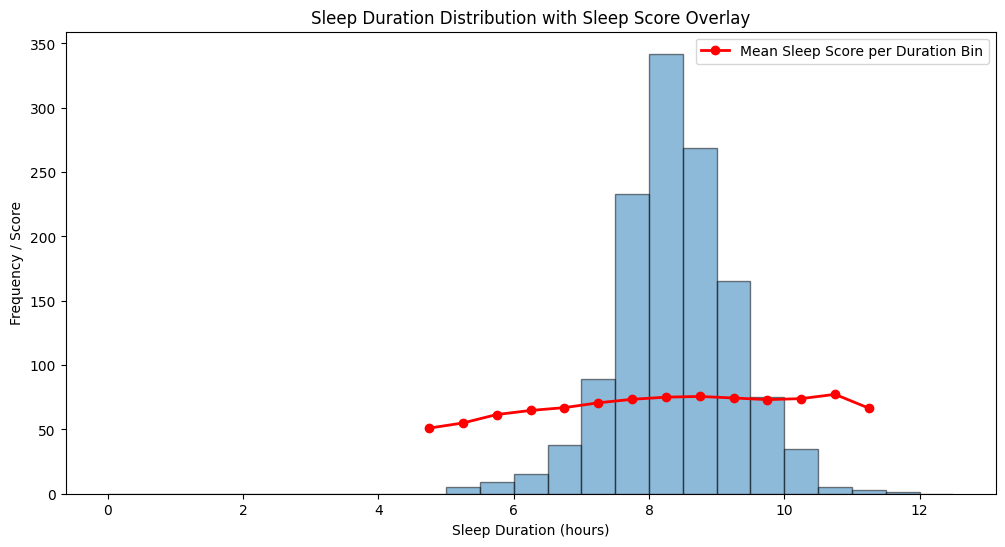

In [38]:

sleep_df = sleep_raw.copy()

sleep_df["sleep_hours"] = sleep_df["totalSleepSeconds"] / 3600

bins = np.arange(0, 13, 0.5)
sleep_df["duration_bin"] = pd.cut(sleep_df["sleep_hours"], bins)

bin_means = sleep_df.groupby("duration_bin", observed=False)["overallScore"].mean()

plt.figure(figsize=(12, 6))

# Histogram
plt.hist(sleep_df["sleep_hours"], bins=bins, alpha=0.5, edgecolor="black")

# Overlay mean score per bin
plt.plot(
    bins[:-1] + 0.25,  # center of each bin
    bin_means,
    marker="o",
    color="red",
    linewidth=2,
    label="Mean Sleep Score per Duration Bin"
)


plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Frequency / Score")
plt.title("Sleep Duration Distribution with Sleep Score Overlay")
plt.legend()
plt.show()

## Sleep variation throughout the week

Sleep broken down into the stages of the Sleep Cycle

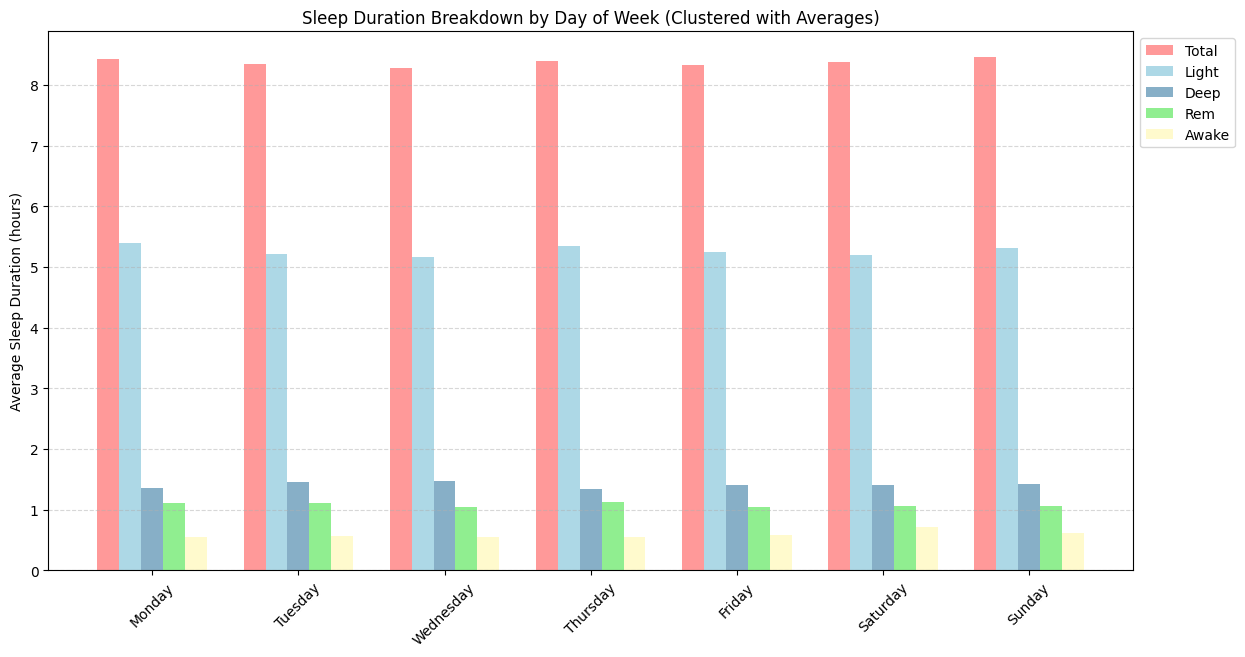

In [31]:
# --- Convert date column to datetime ---
sleep_df["calendarDate"] = pd.to_datetime(sleep_df["calendarDate"])

# --- Extract weekday name ---
sleep_df["day_of_week"] = sleep_df["calendarDate"].dt.day_name()

# --- Convert sleep stage seconds → hours ---
sleep_df["deep_hours"] = sleep_df["deepSleepSeconds"] / 3600
sleep_df["light_hours"] = sleep_df["lightSleepSeconds"] / 3600
sleep_df["rem_hours"] = sleep_df["remSleepSeconds"] / 3600
sleep_df["awake_hours"] = sleep_df["awakeSleepSeconds"] / 3600
sleep_df["total_hours"] = sleep_df["totalSleepSeconds"] / 3600

# --- Group by weekday ---
weekday_sleep = sleep_df.groupby("day_of_week")[[
    "total_hours","light_hours", "deep_hours", "rem_hours", "awake_hours"
]].mean()

# --- Sort weekdays in natural order ---
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sleep = weekday_sleep.reindex(order)

# --- Plot clustered bar chart ---
plt.figure(figsize=(14, 7))

categories = ["total_hours", "light_hours", "deep_hours", "rem_hours", "awake_hours"]
x = np.arange(len(order))
width = 0.15  # width of each bar

colours = ["#FF9999",  "#ADD8E6",  "#87AFC7",   "#90EE90",   "#FFFACD"   ]

# Plot each category as a separate bar cluster
for i, cat in enumerate(categories):
    plt.bar(x + i*width, weekday_sleep[cat], width=width, color = colours[i], label=cat.replace("_hours", "").capitalize())


plt.xticks(x + width*2, order, rotation=45)
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Sleep Duration Breakdown by Day of Week (Clustered with Averages)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


## Sleep trends overtime

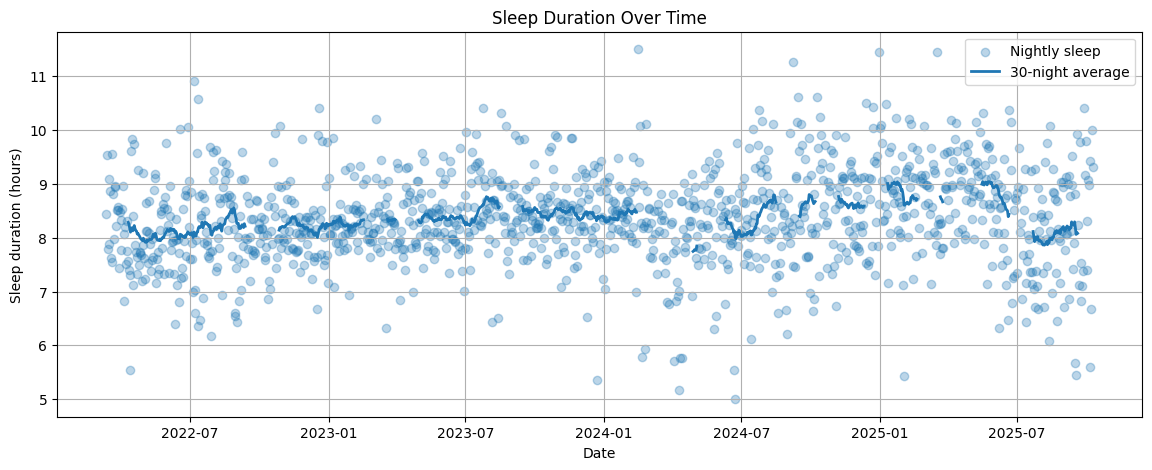

In [35]:


# Calculate rolling average (30 nights)
sleep_df["sleep_hours_30day"] = (
    sleep_df["sleep_hours"]
    .rolling(window=30)
    .mean()
)

# Plot
plt.figure(figsize=(14,5))

# Individual nights
plt.scatter(
    sleep_df["calendarDate"],
    sleep_df["sleep_hours"],
    alpha=0.3,
    label="Nightly sleep"
)

# Trend line
plt.plot(
    sleep_df["calendarDate"],
    sleep_df["sleep_hours_30day"],
    linewidth=2,
    label="30-night average"
)

plt.xlabel("Date")
plt.ylabel("Sleep duration (hours)")
plt.title("Sleep Duration Over Time")

plt.legend()
plt.grid(True)

plt.show()



In [ ]:
wake_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Total Nights Tracked",
            "Typical Wake Time (Median)",
            "Average Wake Time (Mean)",
            "Core Operating Range (80%)",
            "Earliest Core Wake Time (P10)",
            "Latest Core Wake Time (P90)",
            "Absolute Range (Min - Max)",
            "Consistency (Std Dev)",
        ],
        "Value": [
            f"{sleep_df['decimalEndTime'].count():,} nights",
            decimal_to_time(sleep_df["decimalEndTime"].median()),
            decimal_to_time(sleep_df["decimalEndTime"].mean()),
            f"{decimal_to_time(sleep_df['decimalEndTime'].quantile(0.10))} to {decimal_to_time(sleep_df['decimalEndTime'].quantile(0.90))}",
            decimal_to_time(sleep_df["decimalEndTime"].quantile(0.10)),
            decimal_to_time(sleep_df["decimalEndTime"].quantile(0.90)),
            f"{decimal_to_time(sleep_df['decimalEndTime'].min())} to {decimal_to_time(sleep_df['decimalEndTime'].max())}",
            f"±{int(round(sleep_df['decimalEndTime'].std() * 60))} minutes",
        ],
    }
)

wake_summary_df.style.hide(axis="index")